In [ ]:
# SAME but with ECB data
%pip install pandas numpy matplotlib seaborn ecbdata scipy --progress-bar on

In [5]:
import ecbdata
print("ecbdata imported successfully")
print("Python is connected correctly")

ecbdata imported successfully
Python is connected correctly


In [6]:
# ============================================================
#  CEE Government Bond Yield Correlation Analysis
#  Hermann Ossani — Quantitative Finance, WU Vienna
#
#  Countries : Poland, Czech Rep., Hungary, Slovakia,
#              Austria, Bulgaria, Croatia, Romania + Germany
#
#  Data source : ECB Data Portal — completely free, no API key
#  Library     : ecbdata (pip install ecbdata)
#  Methodology : Correlation of monthly yield changes (bps)
#
#  Install everything in one cell:
#  !pip install pandas numpy matplotlib seaborn ecbdata scipy
# ============================================================

# ── CELL 1 — IMPORTS ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns           #Statistical data visualization library built on top of Matplotlib, providing a high-level interface for drawing attractive and informative statistical graphics.
from ecbdata import ecbdata


In [7]:

# ── CELL 2 — ECB SERIES KEYS ────────────────────────────────
# Source: ECB Data Portal — IRS dataset
# Series key format: IRS.M.{country}.L.L40.CI.0.EUR.N.Z
# L40 = 10-year maturity, CI = central government bonds
#
# Country codes (ISO 2-letter):
#   AT=Austria  BG=Bulgaria  CZ=Czech Rep.  HR=Croatia
#   HU=Hungary  PL=Poland    RO=Romania     SK=Slovakia
#   DE=Germany (benchmark)

SERIES = {
    "Germany":    "IRS.M.DE.L.L40.CI.0000.EUR.N.Z", #L40 = 10-year maturity, CI = central government bonds
    "Austria":    "IRS.M.AT.L.L40.CI.0000.EUR.N.Z",
    "Poland":     "IRS.M.PL.L.L40.CI.0000.PLN.N.Z",
    "Czech Rep.": "IRS.M.CZ.L.L40.CI.0000.CZK.N.Z",
    "Hungary":    "IRS.M.HU.L.L40.CI.0000.HUF.N.Z",
    "Slovakia":   "IRS.M.SK.L.L40.CI.0000.EUR.N.Z",
    "Bulgaria":   "IRS.M.BG.L.L40.CI.0000.BGN.N.Z",
    "Croatia":    "IRS.M.HR.L.L40.CI.0000.EUR.N.Z",
    "Romania":    "IRS.M.RO.L.L40.CI.0000.RON.N.Z",
}


In [8]:

# ── CELL 3 — FETCH DATA FROM ECB ────────────────────────────
print("Fetching data from ECB Data Portal...\n")

raw = {}
for country, key in SERIES.items():
    try:
        df_tmp = ecbdata.get_series(key, start="2005-01") 
        df_tmp["TIME_PERIOD"] = pd.to_datetime(df_tmp["TIME_PERIOD"]) #
        df_tmp = df_tmp.set_index("TIME_PERIOD")["OBS_VALUE"]
        df_tmp = pd.to_numeric(df_tmp, errors="coerce")
        raw[country] = df_tmp
        n = df_tmp.notna().sum()
        print(f"  ✓  {country:<14} {n} months of data")
    except Exception as e:
        print(f"  ✗  {country:<14} Could not load — {e}")


Fetching data from ECB Data Portal...

  ✓  Germany        254 months of data
  ✓  Austria        254 months of data
  ✓  Poland         254 months of data
  ✓  Czech Rep.     254 months of data
  ✓  Hungary        254 months of data
  ✓  Slovakia       254 months of data
  ✓  Bulgaria       252 months of data
  ✓  Croatia        243 months of data
  ✓  Romania        251 months of data


In [9]:

# ── CELL 4 — CLEAN & ALIGN ──────────────────────────────────
df = pd.DataFrame(raw).sort_index()

# Show coverage before cleaning
print("\nData coverage per country (non-null months):")
print(df.notna().sum())

# Drop rows where MORE than 2 countries are missing
# This keeps more data than strict dropna()
df_clean = df.dropna(thresh=len(df.columns) - 1) # keep rows with at least 8 NON-missing values
df_clean = df_clean.ffill(limit=1)   # forward-fill max 1 gap
df_clean = df_clean.dropna()    #Drop rows where data gap too large

print(f"\nClean dataset : {len(df_clean)} months")
print(f"Period        : {df_clean.index[0].strftime('%B %Y')} — "
      f"{df_clean.index[-1].strftime('%B %Y')}") #First and last date in the cleaned dataset



Data coverage per country (non-null months):
Germany       254
Austria       254
Poland        254
Czech Rep.    254
Hungary       254
Slovakia      254
Bulgaria      252
Croatia       243
Romania       251
dtype: int64

Clean dataset : 242 months
Period        : December 2005 — January 2026


In [10]:

# ── CELL 5 — YIELD CHANGES (basis points) ───────────────────
df_changes = df_clean.diff().dropna() * 100 # Compute the difference between consecutive rows and convert to basis points (1% = 100 bps), remove first row with dropna
corr = df_changes.corr() # Pearson correlation matrix of the monthly yield changes

print("\nCorrelation matrix (monthly yield changes):")
print(corr.round(2))



Correlation matrix (monthly yield changes):
            Germany  Austria  Poland  Czech Rep.  Hungary  Slovakia  Bulgaria  \
Germany        1.00     0.89    0.53        0.58     0.31      0.56     -0.07   
Austria        0.89     1.00    0.58        0.67     0.48      0.60      0.04   
Poland         0.53     0.58    1.00        0.74     0.64      0.48      0.07   
Czech Rep.     0.58     0.67    0.74        1.00     0.59      0.51      0.12   
Hungary        0.31     0.48    0.64        0.59     1.00      0.40      0.09   
Slovakia       0.56     0.60    0.48        0.51     0.40      1.00      0.10   
Bulgaria      -0.07     0.04    0.07        0.12     0.09      0.10      1.00   
Croatia        0.16     0.23    0.32        0.33     0.27      0.36      0.30   
Romania        0.13     0.21    0.31        0.35     0.31      0.26      0.16   

            Croatia  Romania  
Germany        0.16     0.13  
Austria        0.23     0.21  
Poland         0.32     0.31  
Czech Rep.     0.33 

In [11]:

# ── CELL 6 — COLOUR PALETTE ─────────────────────────────────
COLORS = {
    "Germany":    "#888888",
    "Austria":    "#264653",
    "Poland":     "#E63946",
    "Czech Rep.": "#457B9D",
    "Hungary":    "#2A9D8F",
    "Slovakia":   "#E9C46A",
    "Bulgaria":   "#F4A261",
    "Croatia":    "#A8DADC",
    "Romania":    "#6A0572",
}


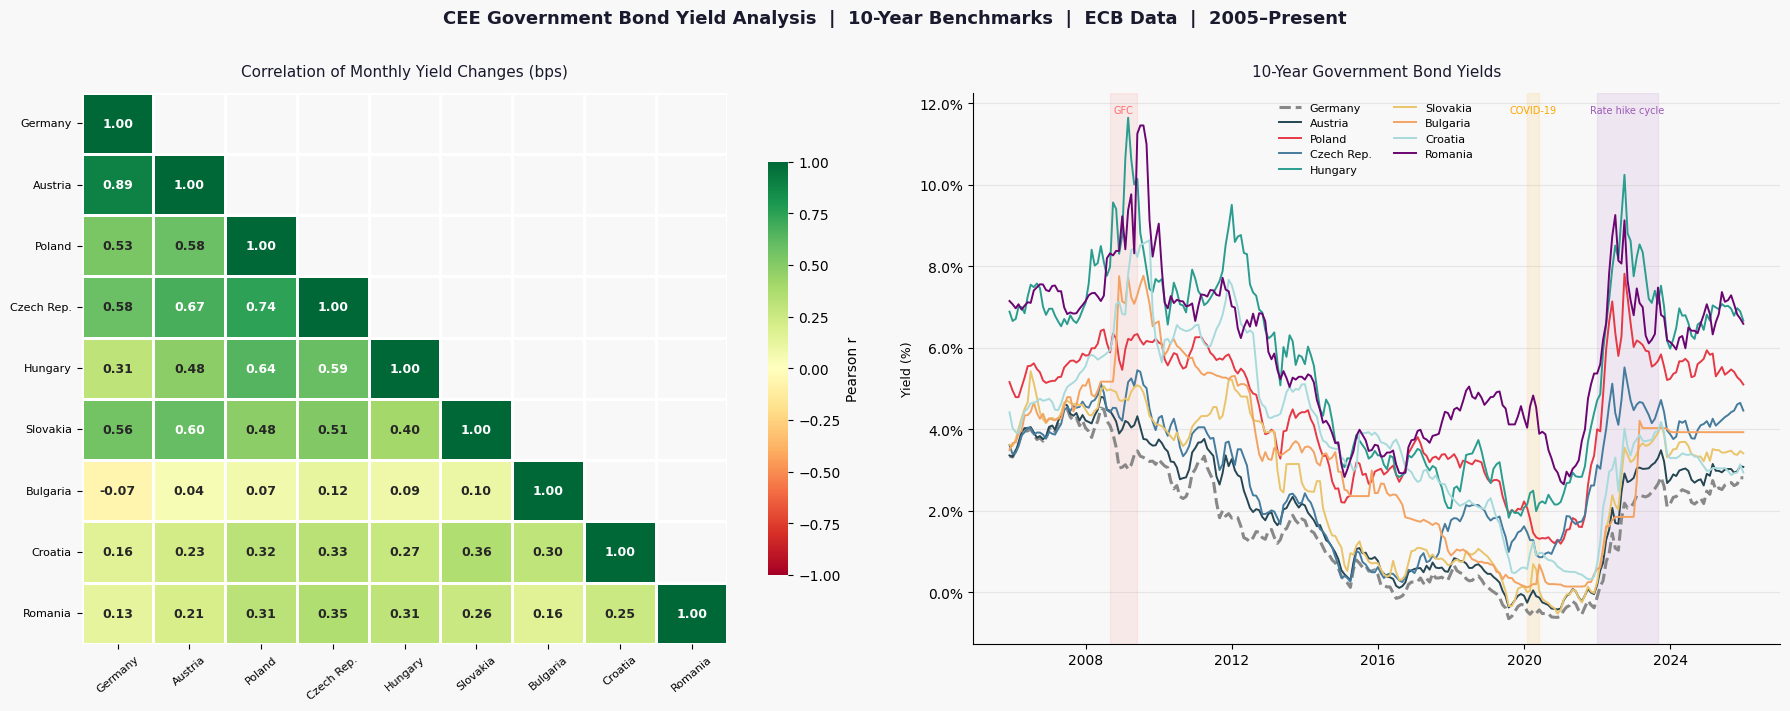

✓ Saved: cee_bond_heatmap_ecb.png


In [12]:

# ── CELL 7 — FIGURE 1: HEATMAP + TIME SERIES ────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#F8F8F8")
for ax in axes:
    ax.set_facecolor("#F8F8F8")

fig.suptitle(
    "CEE Government Bond Yield Analysis  |  10-Year Benchmarks  |  ECB Data  |  2005–Present",
    fontsize=13, fontweight="bold", y=1.01, color="#1A1A2E"
)

# Heatmap — lower triangle only
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, ax=axes[0], mask=mask,
    annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=-1, vmax=1,
    linewidths=0.8, linecolor="white",
    annot_kws={"size": 9, "weight": "bold"},
    cbar_kws={"label": "Pearson r", "shrink": 0.75}
)
axes[0].set_title("Correlation of Monthly Yield Changes (bps)",
                  fontsize=11, pad=12, color="#1A1A2E")
axes[0].tick_params(axis="x", rotation=40, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

# Time series
for col in df_clean.columns:
    lw = 2.2 if col == "Germany" else 1.4
    ls = "--" if col == "Germany" else "-"
    axes[1].plot(df_clean.index, df_clean[col],
                 label=col, color=COLORS[col],
                 linewidth=lw, linestyle=ls)

# Shade macro events
events = [ # (start, end, color, label)
    ("2008-09-01", "2009-06-01", "#FF6B6B", "GFC"),
    ("2020-02-01", "2020-06-01", "#FFA500", "COVID-19"),
    ("2022-01-01", "2023-09-01", "#9B59B6", "Rate hike cycle"),
]
for start, end, color, label in events:
    axes[1].axvspan(start, end, alpha=0.10, color=color)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    axes[1].text(mid, axes[1].get_ylim()[1] * 0.96,
                 label, fontsize=7, color=color, ha="center")

axes[1].set_title("10-Year Government Bond Yields",
                  fontsize=11, pad=12, color="#1A1A2E")
axes[1].set_ylabel("Yield (%)", fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
axes[1].legend(frameon=False, fontsize=8, ncol=2)
axes[1].grid(axis="y", alpha=0.25)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("cee_bond_heatmap_ecb.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved: cee_bond_heatmap_ecb.png")


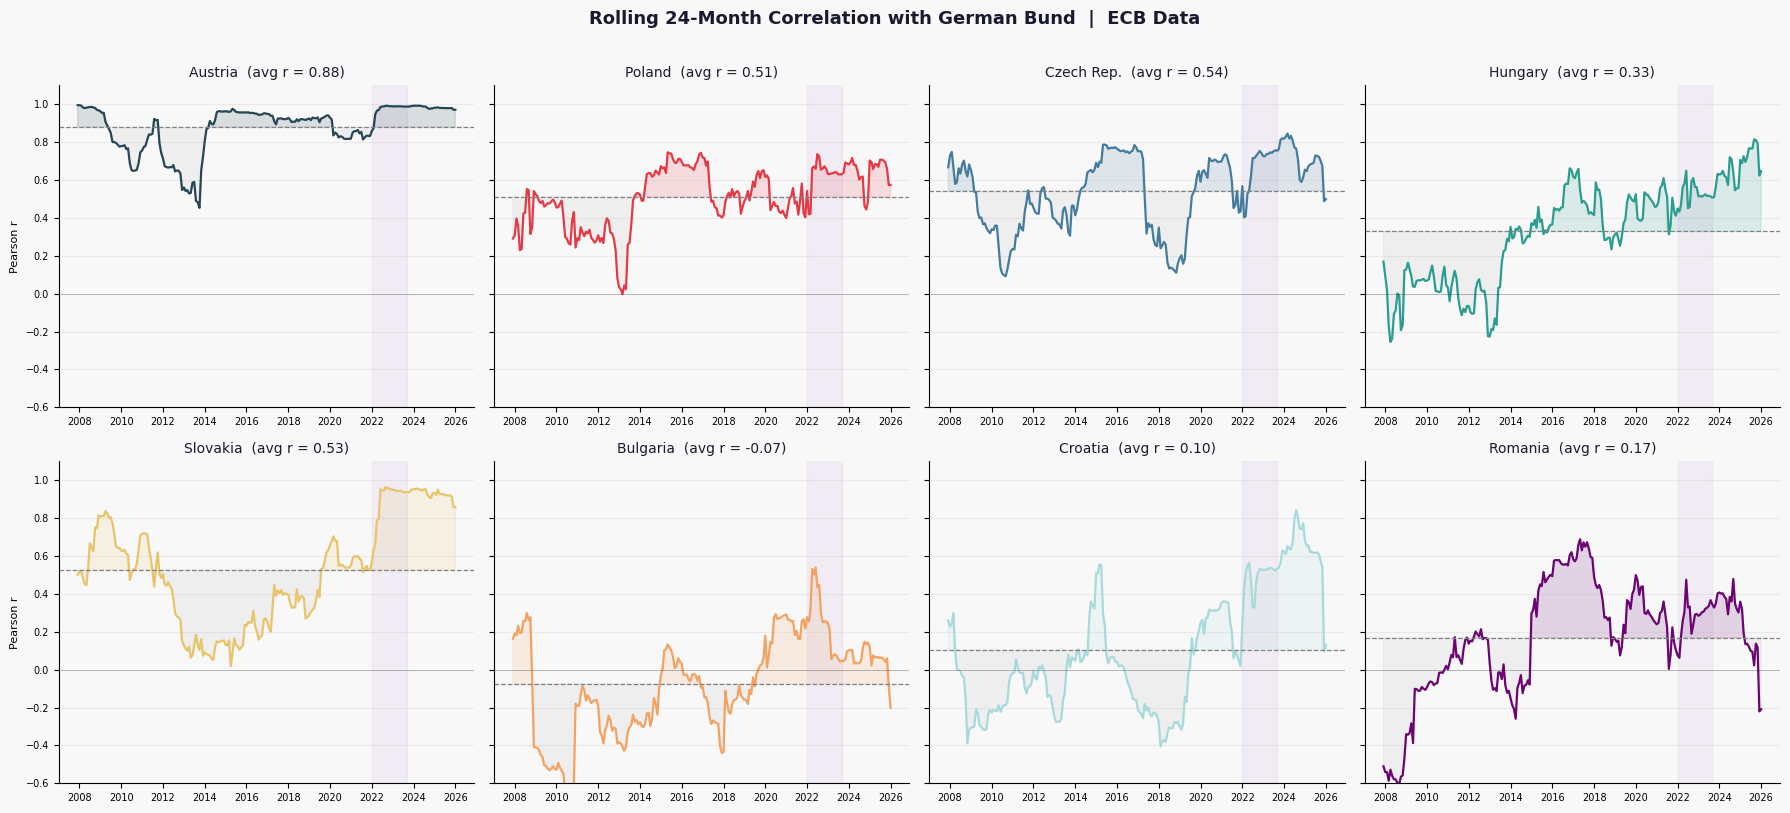

✓ Saved: cee_rolling_correlation_ecb.png


In [13]:

# ── CELL 8 — FIGURE 2: ROLLING CORRELATIONS VS GERMANY ──────
cee_only = [c for c in df_clean.columns if c != "Germany"]

fig2, axes2 = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
fig2.patch.set_facecolor("#F8F8F8")
fig2.suptitle(
    "Rolling 24-Month Correlation with German Bund  |  ECB Data",
    fontsize=13, fontweight="bold", y=1.01, color="#1A1A2E"
)

for i, country in enumerate(cee_only):
    ax = axes2.flatten()[i]
    ax.set_facecolor("#F8F8F8")
    color = COLORS[country]

    rolling = (df_changes[country]
               .rolling(24)
               .corr(df_changes["Germany"])
               .dropna())
    mean_r = rolling.mean()

    ax.plot(rolling.index, rolling, color=color, linewidth=1.6)
    ax.axhline(mean_r, color="gray", linestyle="--", linewidth=0.9)
    ax.fill_between(rolling.index, rolling, mean_r,
                    where=(rolling >= mean_r), alpha=0.15, color=color)
    ax.fill_between(rolling.index, rolling, mean_r,
                    where=(rolling <  mean_r), alpha=0.08, color="gray")
    ax.axvspan("2022-01-01", "2023-09-01", alpha=0.07, color="#9B59B6")

    ax.set_title(f"{country}  (avg r = {mean_r:.2f})",
                 fontsize=10, color="#1A1A2E", pad=6)
    ax.set_ylim(-0.6, 1.1)
    ax.axhline(0, color="black", linewidth=0.5, alpha=0.3)
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=7)
    ax.set_ylabel("Pearson r" if i % 4 == 0 else "", fontsize=8)

plt.tight_layout()
plt.savefig("cee_rolling_correlation_ecb.png", dpi=150,
            bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()
print("✓ Saved: cee_rolling_correlation_ecb.png")


In [14]:

# ── CELL 9 — SUMMARY STATISTICS ─────────────────────────────
print("\n" + "=" * 60)
print("KEY FINDINGS  —  ECB Data")
print("=" * 60)
print(f"\n{'Country':<14} {'Avg Yield':>10} {'Std Dev':>10} {'Corr vs DE':>12}")
print("-" * 50)
for country in cee_only:
    avg  = df_clean[country].mean()
    std  = df_clean[country].std()
    r_de = corr.loc[country, "Germany"]
    print(f"{country:<14} {avg:>9.2f}%  {std:>9.2f}%  {r_de:>11.3f}")

print("\nTop 5 strongest correlated pairs:")
pairs = []
for i in range(len(cee_only)):
    for j in range(i + 1, len(cee_only)):
        a, b = cee_only[i], cee_only[j]
        pairs.append((a, b, corr.loc[a, b]))
pairs.sort(key=lambda x: x[2], reverse=True)
for a, b, r in pairs[:5]:
    print(f"  {a} ↔ {b:<14}  r = {r:.3f}")

print("\nBottom 3 weakest correlated pairs:")
for a, b, r in pairs[-3:]:
    print(f"  {a} ↔ {b:<14}  r = {r:.3f}")

print("\nData source: ECB Data Portal (data-api.ecb.europa.eu)")
print("No API key required.")
print("=" * 60)


KEY FINDINGS  —  ECB Data

Country         Avg Yield    Std Dev   Corr vs DE
--------------------------------------------------
Austria             2.09%       1.54%        0.888
Poland              4.42%       1.58%        0.533
Czech Rep.          2.87%       1.51%        0.581
Hungary             5.69%       2.31%        0.307
Slovakia            2.63%       1.78%        0.557
Bulgaria            3.27%       1.99%       -0.067
Croatia             3.91%       1.99%        0.158
Romania             5.90%       1.83%        0.133

Top 5 strongest correlated pairs:
  Poland ↔ Czech Rep.      r = 0.744
  Austria ↔ Czech Rep.      r = 0.673
  Poland ↔ Hungary         r = 0.643
  Austria ↔ Slovakia        r = 0.600
  Czech Rep. ↔ Hungary         r = 0.588

Bottom 3 weakest correlated pairs:
  Hungary ↔ Bulgaria        r = 0.086
  Poland ↔ Bulgaria        r = 0.074
  Austria ↔ Bulgaria        r = 0.043

Data source: ECB Data Portal (data-api.ecb.europa.eu)
No API key required.
